# Customer Churn Prediction

In [23]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

## Exploratory Data Analysis

In [24]:
data = pd.read_csv("../ml/data/raw/Telco-Customer-Churn.csv")

In [25]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [26]:
data.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [27]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [28]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(0)
index_to_drop = data[(data["tenure"] > 0) & (data["TotalCharges"] == 0)].index
data.drop(index_to_drop,inplace=True)

In [29]:
churn_count = data["Churn"].value_counts()
print(churn_count)
churn_rate = data["Churn"].value_counts(normalize=True)*100
print(f"churn_count\n")
print(churn_rate)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
churn_count

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


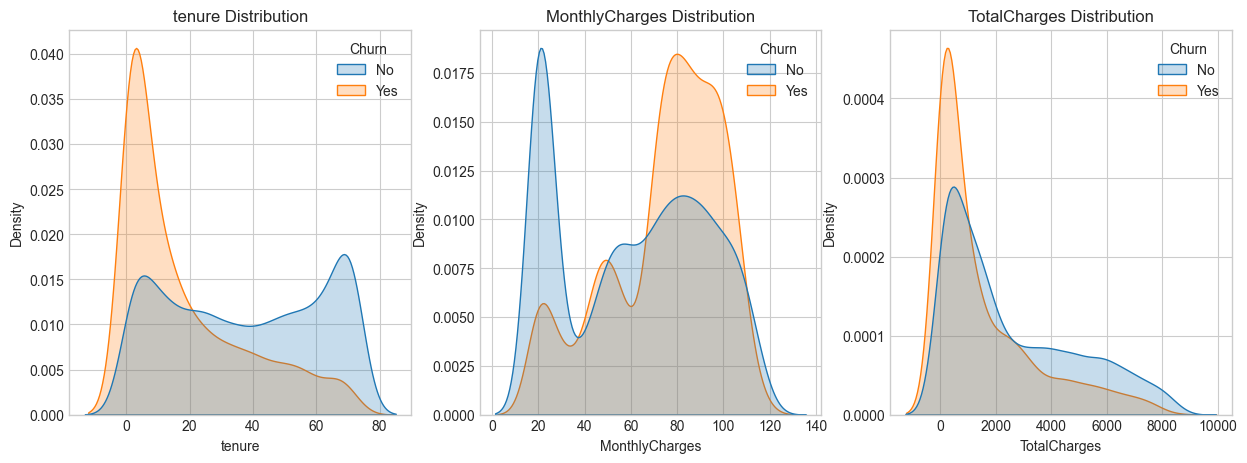

In [30]:
numerical_features_list = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1,3,figsize=(15,5))
for i,col in enumerate(numerical_features_list):
    sns.kdeplot(data=data,x=col,hue='Churn',fill=True,common_norm=False,ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
plt.show()


In [31]:
from sklearn.preprocessing import LabelEncoder
categorical_features = [
    "gender","Partner","Dependents","PhoneService","MultipleLines",
    "InternetService","OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies","Contract",
    "PaperlessBilling","PaymentMethod","Churn"
]
encoded_data = data.copy()
encoded_data.drop("customerID", axis=1, inplace=True)
for col in categorical_features:
    encoded_data[col] = encoded_data[col].fillna("Unknown")
    le = LabelEncoder()
    encoded_data[col] = le.fit_transform(encoded_data[col])
encoded_data.to_csv("../ml/data/processed/processed_data.csv", index=False)

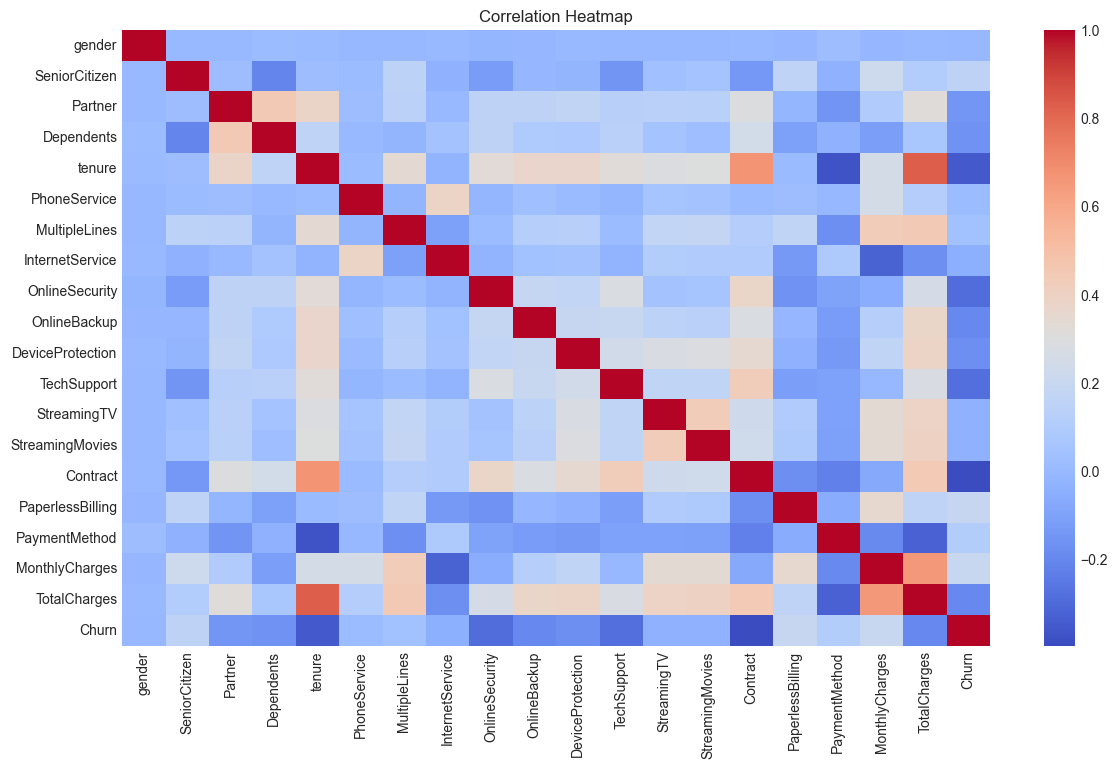

In [32]:
import seaborn as sns
fig,ax = plt.subplots(figsize=(14,8))
sns.heatmap(encoded_data.corr(),cmap="coolwarm",annot=False)
ax.set_title("Correlation Heatmap")
plt.show()

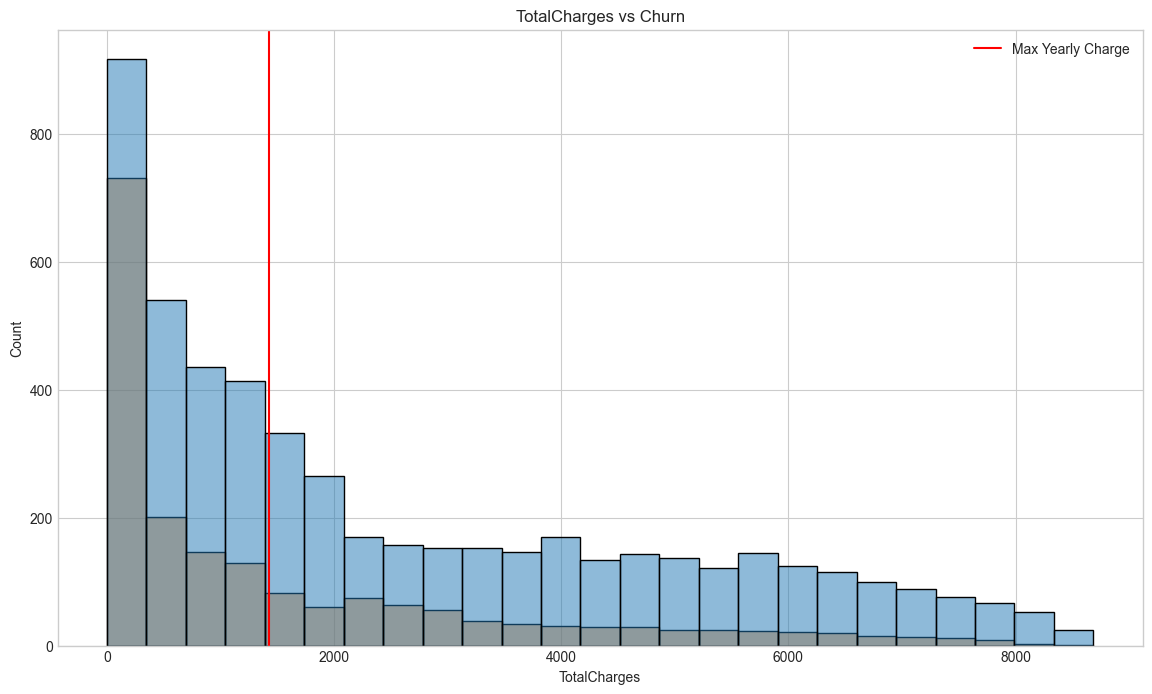

In [33]:
fig,ax = plt.subplots(figsize=(14,8))
sns.histplot(data=data, x="TotalCharges", hue="Churn")
ax.axvline(data["MonthlyCharges"].max()*12,color="r",label="Max Yearly Charge")
ax.set_title("TotalCharges vs Churn")
ax.legend()
plt.show()

**we can see that They are more likely to Churn around 12-14months of subscribtion**
, after that the churn decreases

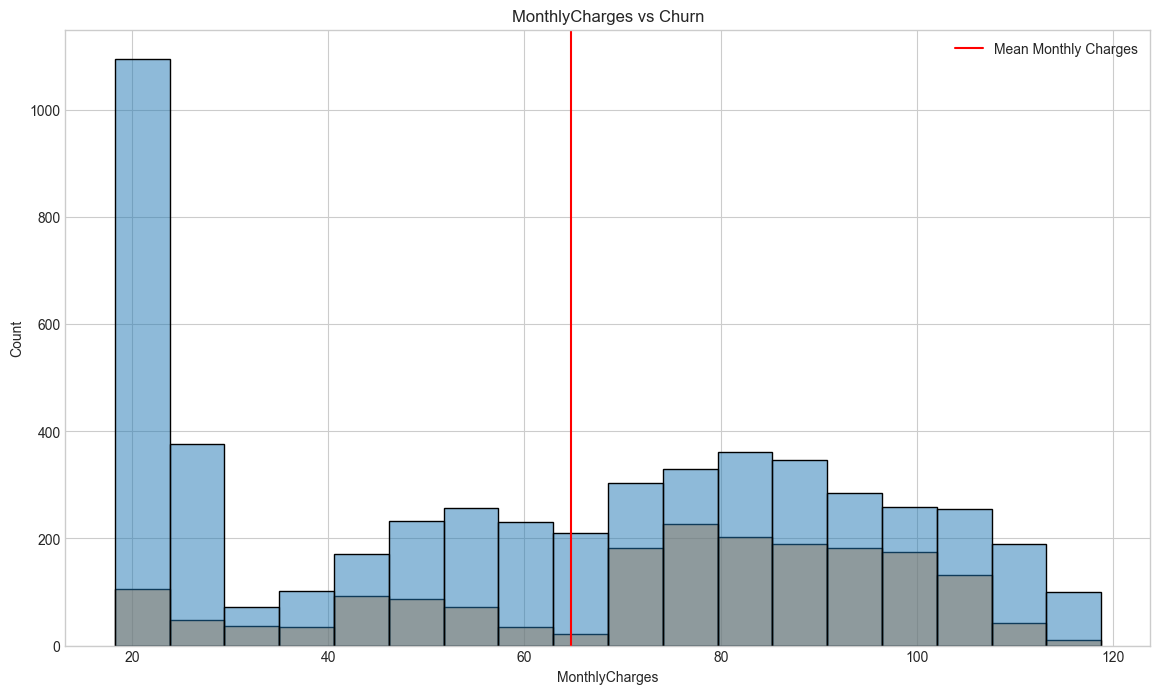

In [34]:
fig,ax = plt.subplots(figsize=(14,8))
sns.histplot(data=data, x="MonthlyCharges",hue="Churn")
ax.axvline(data["MonthlyCharges"].mean(),color="r",label="Mean Monthly Charges")
ax.set_title("MonthlyCharges vs Churn")
ax.legend()
plt.show()

**we can see that when we surpass the mean monthly Charges the customer are more likely to Churn**
- so higher monthly price ---> more likely to Churn

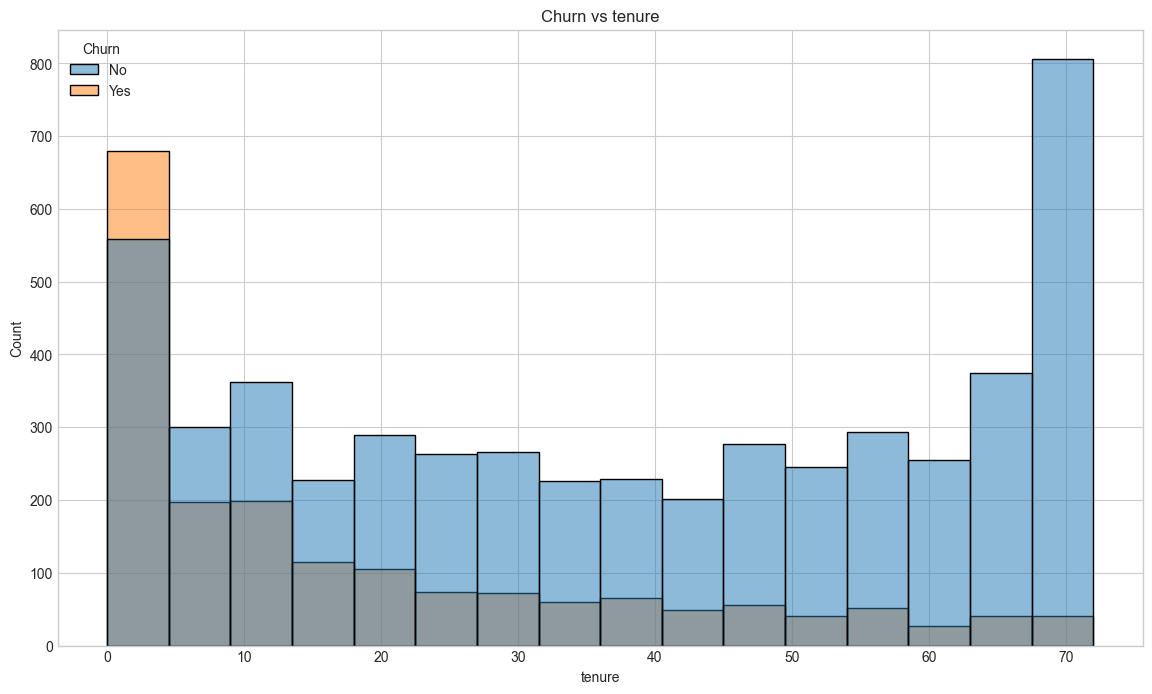

In [35]:
fig,ax = plt.subplots(figsize=(14,8))
sns.histplot(data=data, x="tenure",hue="Churn")
ax.set_title("Churn vs tenure")
plt.show()

**over time the customers are more likely to not churn**
- after 24months we can see a big decrease in churn percentage

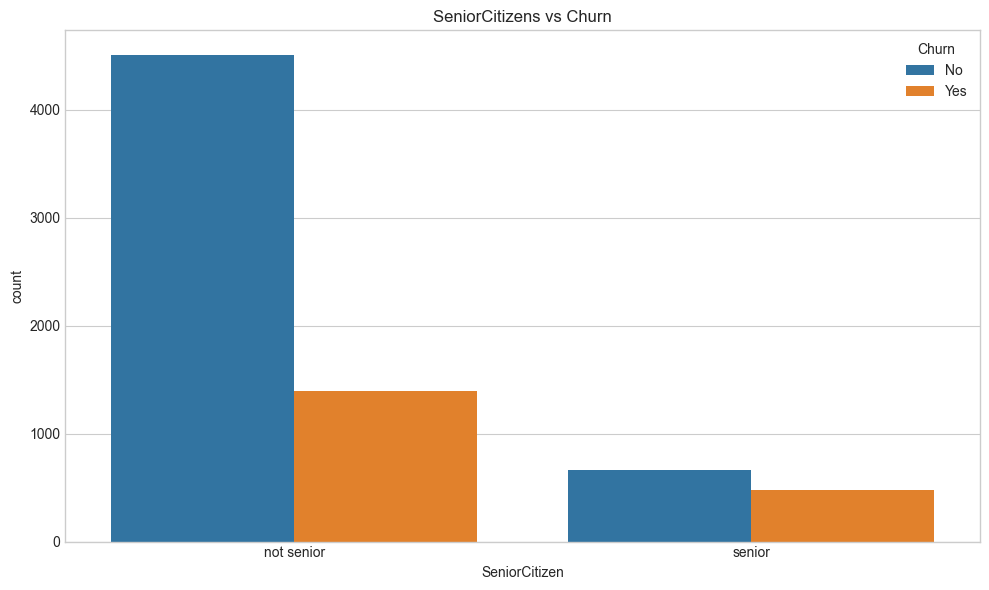

In [36]:
fig,ax = plt.subplots(figsize=(10,6))
sns.countplot(data=data, x="SeniorCitizen" , hue="Churn")
ax.set_xticks([0,1])
ax.set_xticklabels(["not senior","senior"])
ax.set_title("SeniorCitizens vs Churn")
plt.tight_layout()
plt.show()

**we can see**
- most of senior citizens churned

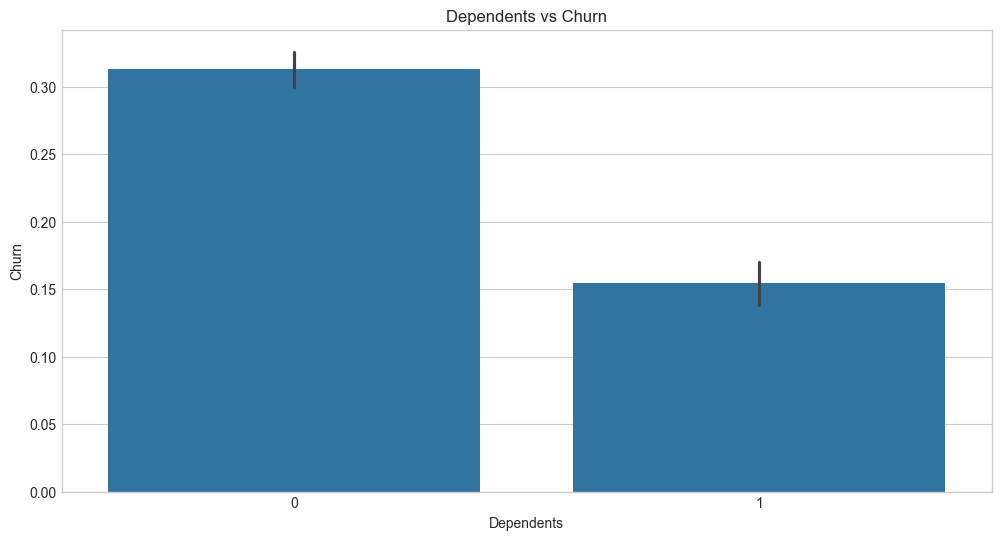

In [37]:
fig,ax = plt.subplots(figsize=(12,6))
sns.barplot(data=encoded_data, x="Dependents" , y="Churn")
ax.set_title("Dependents vs Churn")
plt.show()

** we can see that there is a correlation With dependency and churn **
- 35% of people that didn't churn had dependency

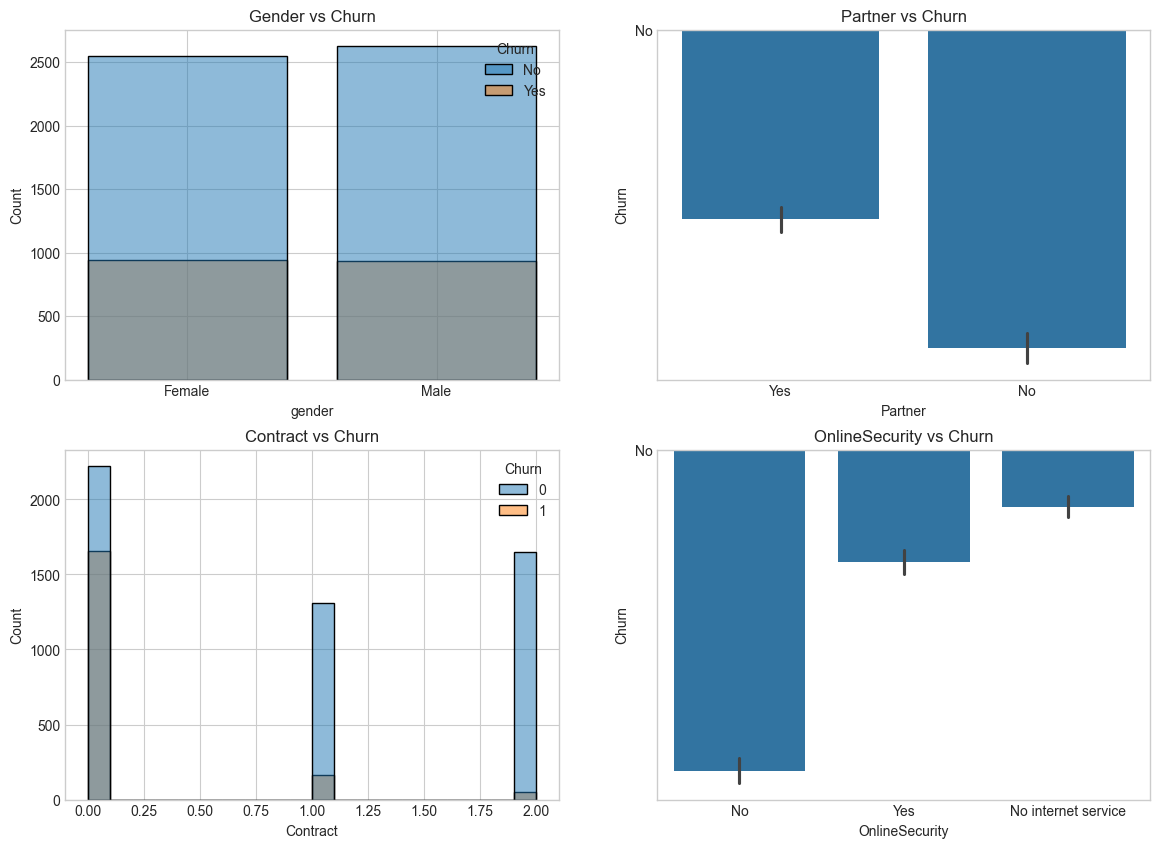

In [38]:
fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(14,10))
sns.histplot(data=data,x="gender",hue="Churn",shrink=0.8,ax=ax1)
ax1.set_title("Gender vs Churn")
sns.barplot(data=data,x="Partner",y="Churn",ax=ax2)
ax2.set_title("Partner vs Churn")
sns.histplot(data=encoded_data,x="Contract",hue="Churn",ax=ax3)
ax3.set_title("Contract vs Churn")
sns.barplot(data=data,x="OnlineSecurity",y="Churn",ax=ax4)
ax4.set_title("OnlineSecurity vs Churn")
plt.show()

**Take-Aways**
- Gender doesn't matter a lot here they pretty much the same (Male vs Female)
- Customer with a partner churn less
- more the time of the contract more likely to not churn
- Much Higher rate when no OnlineSecurity

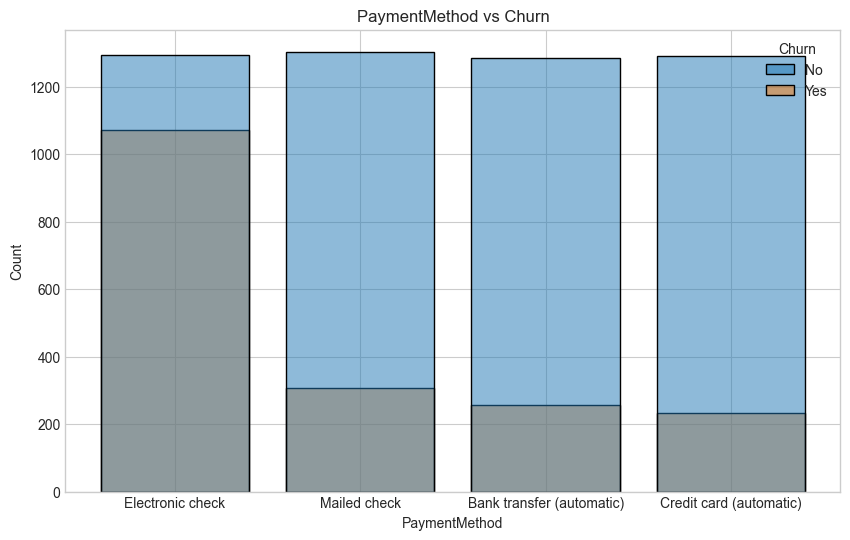

In [39]:
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(data=data,x="PaymentMethod",hue="Churn",shrink=0.8,ax=ax)
ax.set_title("PaymentMethod vs Churn")
plt.show()

**we can see that the majority who churned**
- had a Electronic payment method
- customer that opted for Credit Card or Bank Transfer or Mailed Check as a payment were less likely to move out

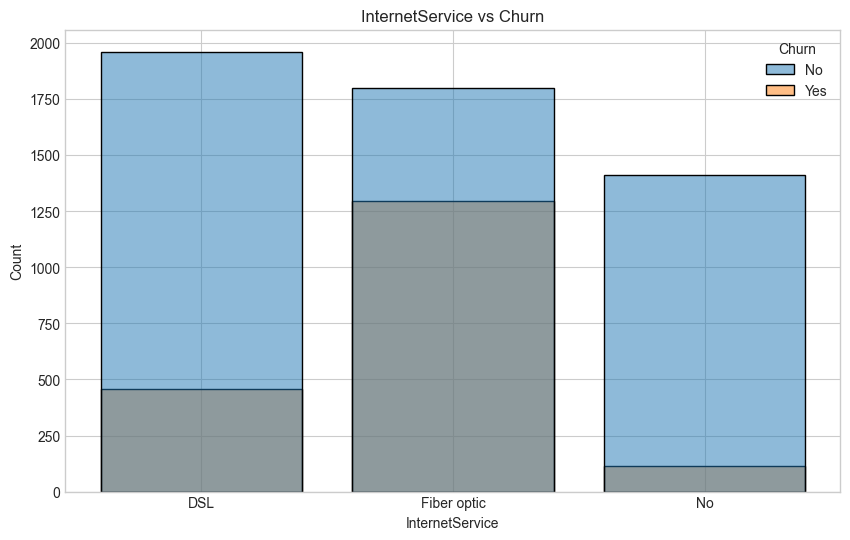

In [40]:
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(data=data,x="InternetService",hue="Churn",shrink=0.8,ax=ax)
ax.set_title("InternetService vs Churn")
plt.show()

**we can see that**
- most people with fiber optic services are more likely to churn (probably a dissatisfaction of the internet service).
- Customers having DSL service have low churn rate compared to fiber optic customers.

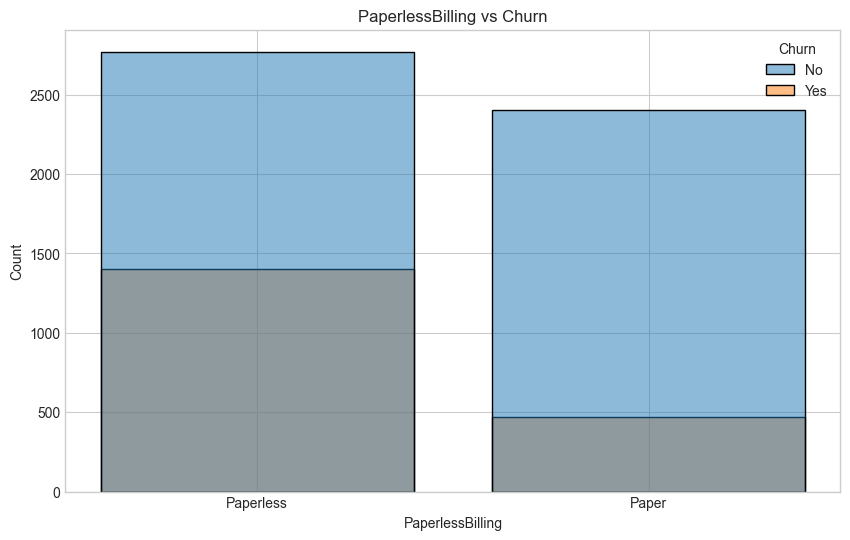

In [41]:
fig,ax = plt.subplots(figsize=(10,6))
sns.histplot(data=data,x="PaperlessBilling",shrink=0.8,hue="Churn")
ax.set_xticks([0,1])
ax.set_xticklabels(["Paperless","Paper"])
ax.set_title("PaperlessBilling vs Churn")
plt.show()

**cutomers with paperless billing are more likely to churn**

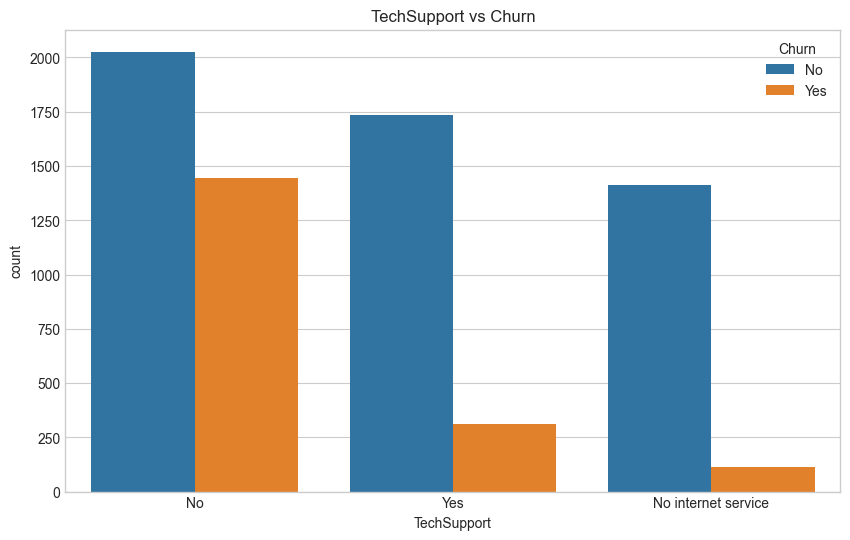

In [42]:
fig,ax = plt.subplots(figsize=(10,6))
sns.countplot(data=data,x="TechSupport",hue="Churn",ax=ax)
ax.set_title("TechSupport vs Churn")
plt.show()

**we can see that customers with no tech support are more likely to migrate to another service**

# Data Preprocessing + Modeling

**start with a baseline Model (Logistic Regression)**

In [43]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler,FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
X = data.drop(["Churn","customerID"],axis=1)
y = data["Churn"].map({"No":0,"Yes":1})
normal_features = ["tenure","MonthlyCharges"]
skewed_features = ["TotalCharges"]
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

log_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("skewed",FunctionTransformer(np.log1p,validate=True))
])
normal_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="mean")),
    ("scaler",StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="constant",fill_value="missing")),
    ("onehot",OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("skewed",log_transformer,skewed_features),
        ("num",normal_transformer,normal_features),
        ("categorical",categorical_transformer,categorical_features)
    ])

baseline_model = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",LogisticRegression())
])

In [44]:
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_validate
X_train, X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)
baseline_model.fit(X_train,y_train)
scoring = ["accuracy","roc_auc","f1","precision","recall"]
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_results = cross_validate(baseline_model,X,y,cv=5,scoring=scoring,return_train_score=True)
cv_results

{'fit_time': array([0.02866793, 0.02910399, 0.03771901, 0.03308296, 0.03149438]),
 'score_time': array([0.01295686, 0.01477695, 0.01283598, 0.01234412, 0.01307964]),
 'test_accuracy': array([0.80766501, 0.80482612, 0.79843861, 0.81747159, 0.80823864]),
 'train_accuracy': array([0.80883919, 0.80741924, 0.81025914, 0.80567879, 0.81047028]),
 'test_roc_auc': array([0.8639102 , 0.86279031, 0.83519724, 0.84330212, 0.84360875]),
 'train_roc_auc': array([0.84880568, 0.84889149, 0.85605631, 0.85423358, 0.85416461]),
 'test_f1': array([0.59491779, 0.59618209, 0.58235294, 0.61236802, 0.59214502]),
 'train_f1': array([0.59828422, 0.59560194, 0.60363367, 0.59459459, 0.60238273]),
 'test_precision': array([0.67457627, 0.66123779, 0.64705882, 0.7       , 0.68055556]),
 'train_precision': array([0.6762226 , 0.67255892, 0.67720466, 0.66639004, 0.67926113]),
 'test_recall': array([0.53208556, 0.54278075, 0.52941176, 0.54423592, 0.52406417]),
 'train_recall': array([0.53645485, 0.53444816, 0.54448161, 0

In [48]:
def printMetrics(cv_results):
    return {"roc_auc score is" :cv_results["test_roc_auc"].mean().round(2),
            "accuracy score is" :cv_results["test_accuracy"].mean().round(2),
            "precision score is" :cv_results["test_precision"].mean().round(2),
            "recall score is" :cv_results["test_recall"].mean().round(2),
            "f1 score is":cv_results["test_f1"].mean().round(2)}
printMetrics(cv_results)

{'roc_auc score is': np.float64(0.85),
 'accuracy score is': np.float64(0.81),
 'precision score is': np.float64(0.67),
 'recall score is': np.float64(0.53),
 'f1 score is': np.float64(0.6)}

In [46]:
import joblib
joblib.dump(baseline_model,"../ml/models/artifacts/model_v1.pkl")

['../ml/models/artifacts/model_v1.pkl']